##Cell 1 — Setup

In [3]:
# ===================== SETUP & GPU CHECK =====================
from google.colab import files, drive
import os, shutil, zipfile
import tensorflow as tf

# Check GPU availability for Free Tier
gpu_name = tf.test.gpu_device_name()
if gpu_name != '/device:GPU:0':
  print('⚠️ GPU device not found. Go to Runtime > Change runtime type > T4 GPU')
else:
  print(f'⚡ Found GPU at: {gpu_name}')

drive.mount('/content/drive')
DRIVE_SAVE_DIR = '/content/drive/MyDrive/dental_model'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"✅ Drive mounted → {DRIVE_SAVE_DIR}")

print("\nUpload kaggle.json")
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Clean any previous runs
for folder in ['/content/dental', '/content/dental_clean']:
    if os.path.exists(folder):
        shutil.rmtree(folder)

# ✅ Proper classification dataset — one label per image
# ~12,894 intraoral images, 7 classes, used in published research
print("\nDownloading dataset...")
!kaggle datasets download -d salmansajid05/oral-diseases -q

with zipfile.ZipFile('oral-diseases.zip', 'r') as z:
    z.extractall('/content/dental')

print("\n📂 Dataset structure:")
for root, dirs, files_list in os.walk('/content/dental'):
    level = root.replace('/content/dental', '').count(os.sep)
    if level > 2:
        continue
    indent = '   ' * level
    imgs = len([f for f in files_list if f.lower().endswith(('.jpg','.jpeg','.png'))])
    name = os.path.basename(root)
    if imgs > 0:
        print(f"{indent}📁 {name}/ → {imgs} images")
    elif dirs and level <= 1:
        print(f"{indent}📁 {name}/")

print("\n✅ Dataset Ready!")

⚡ Found GPU at: /device:GPU:0
Mounted at /content/drive
✅ Drive mounted → /content/drive/MyDrive/dental_model

Upload kaggle.json


Saving kaggle.json to kaggle (2).json

Dataset URL: https://www.kaggle.com/datasets/salmansajid05/oral-diseases
License(s): unknown

📂 Dataset structure:
📁 dental/
   📁 Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset/
   📁 Tooth Discoloration/
   📁 Calculus/
      📁 Calculus/ → 1296 images
   📁 hypodontia/
      📁 hypodontia/ → 1251 images
   📁 Mouth Ulcer/
   📁 Data caries/
   📁 Gingivitis/
      📁 Gingivitis/ → 2349 images

✅ Dataset Ready!


##Cell 2 — Preprocessing

In [9]:
# ===================== DATA PREPROCESSING =====================
import os, shutil, pandas as pd
from sklearn.model_selection import train_test_split

DENTAL_ROOT = '/content/dental'

print("🔍 Parsing Kaggle's nested folder structure...")
all_records = []

# ── Map file paths to correct disease names ──────────────────
def get_true_class(path):
    path_lower = path.lower()
    if 'caries' in path_lower: return 'Caries'
    if 'calculus' in path_lower or 'tartar' in path_lower: return 'Calculus'
    if 'gingivitis' in path_lower: return 'Gingivitis'
    if 'ulcer' in path_lower: return 'Ulcer'
    if 'discoloration' in path_lower: return 'Tooth_Discoloration'
    if 'hypodontia' in path_lower: return 'Hypodontia'
    return None

for root, dirs, files in os.walk(DENTAL_ROOT):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(root, f)
            true_class = get_true_class(full_path)

            if true_class: # Only add if it maps to a real disease
                all_records.append({
                    'filename' : f,
                    'class'    : true_class,
                    'img_path' : full_path
                })

full_df = pd.DataFrame(all_records)

# ── Deduplicate to avoid Kaggle upload errors ─────────────────
full_df = full_df.drop_duplicates(subset=['filename', 'class'])

valid_classes = full_df['class'].value_counts()
print(f"\n📊 Found {len(full_df)} clean, unique images across {len(valid_classes)} classes.")
print(valid_classes)

# ── Stratified 70 / 15 / 15 split ─────────────────────────────
train_df, temp_df = train_test_split(
    full_df, test_size=0.30,
    stratify=full_df['class'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df['class'], random_state=42
)

print(f"\n✅ Splits — Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── Copy into clean folder structure ──────────────────────────
OUTPUT_PATH = '/content/dental_clean'
if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)

def copy_split(df, split_name):
    ok = 0
    for _, row in df.iterrows():
        dst_dir = os.path.join(OUTPUT_PATH, split_name, row['class'])
        os.makedirs(dst_dir, exist_ok=True)

        # Create a unique destination filename to prevent overwriting
        base, ext = os.path.splitext(row['filename'])
        unique_filename = f"{row['class']}_{ok}{ext}"
        dst = os.path.join(dst_dir, unique_filename)

        if os.path.exists(row['img_path']):
            shutil.copy(row['img_path'], dst)
            ok += 1

    print(f"📂 {split_name} — {ok} images copied")

print("\n⚙️ Copying files to clean splits (this might take a minute)...")
copy_split(train_df, 'train')
copy_split(val_df,   'valid')
copy_split(test_df,  'test')

DATASET_PATH = OUTPUT_PATH
print(f"\n✅ Clean dataset ready at: {DATASET_PATH}")

🔍 Parsing Kaggle's nested folder structure...

📊 Found 12992 clean, unique images across 6 classes.
class
Caries                 3273
Ulcer                  2806
Gingivitis             2349
Tooth_Discoloration    2017
Calculus               1296
Hypodontia             1251
Name: count, dtype: int64

✅ Splits — Train: 9094 | Val: 1949 | Test: 1949

⚙️ Copying files to clean splits (this might take a minute)...
📂 train — 9094 images copied
📂 valid — 1949 images copied
📂 test — 1949 images copied

✅ Clean dataset ready at: /content/dental_clean


##Cell 3 — Generators

Found 9094 images belonging to 6 classes.
Found 1949 images belonging to 6 classes.
Found 1949 images belonging to 6 classes.
✅ 6 classes: ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth_Discoloration', 'Ulcer']
   Train : 9094 images  (285 batches)
   Val   : 1949 images  (61 batches)
   Test  : 1949 images  (61 batches)


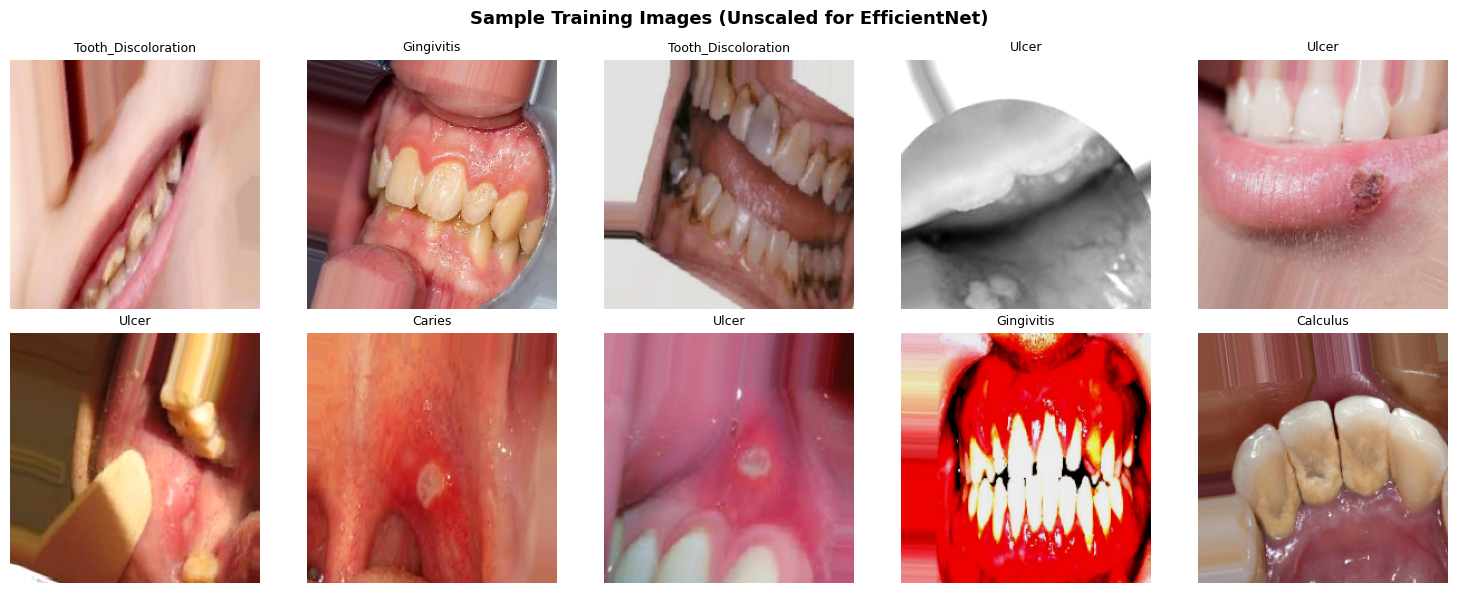

In [10]:
# ===================== CONFIG & GENERATORS =====================
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE     = 224
BATCH_SIZE   = 32
DATASET_PATH = '/content/dental_clean'

# ⚠️ CRITICAL FIX: Removed rescale=1./255
# EfficientNet expects inputs in [0, 255] and handles its own normalization.
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    shear_range=0.15,
    fill_mode='nearest'
)

# No rescaling for validation/test either
val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
val_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'valid'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES  = len(CLASS_NAMES)

print(f"✅ {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"   Train : {train_gen.samples} images  ({len(train_gen)} batches)")
print(f"   Val   : {val_gen.samples} images  ({len(val_gen)} batches)")
print(f"   Test  : {test_gen.samples} images  ({len(test_gen)} batches)")

# ── Sample grid ────────────────────────────────────────────────
imgs, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    # Convert back to uint8 for plotting purposes only since we removed rescale
    ax.imshow(imgs[i].astype('uint8'))
    ax.set_title(CLASS_NAMES[np.argmax(labels[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images (Unscaled for EfficientNet)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 4 — Model

In [11]:
# ===================== CLASS WEIGHTS + MODEL =====================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import tensorflow.keras.backend as K
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced',
                                     classes=np.unique(train_gen.classes),
                                     y=train_gen.classes)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    bar = '█' * int(w * 6)
    print(f"   [{i}] {cls:<25} → {w:.4f}  {bar}")

# ── Custom macro F1 metric ─────────────────────────────────────
def f1_score_metric(y_true, y_pred):
    num_classes = tf.shape(y_pred)[-1]
    y_pred_oh = tf.one_hot(tf.argmax(y_pred, axis=-1), num_classes)
    y_true_f  = tf.cast(y_true,    tf.float32)
    y_pred_f  = tf.cast(y_pred_oh, tf.float32)
    tp = tf.reduce_sum(y_true_f * y_pred_f,        axis=0)
    fp = tf.reduce_sum((1-y_true_f) * y_pred_f,    axis=0)
    fn = tf.reduce_sum(y_true_f * (1-y_pred_f),    axis=0)
    precision = tp / (tp + fp + K.epsilon())
    recall    = tp / (tp + fn + K.epsilon())
    f1 = 2*precision*recall / (precision + recall + K.epsilon())
    return tf.reduce_mean(f1)

# ── EfficientNetB0 — frozen base, trainable head ───────────────
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False # Freeze completely for Phase 1

x      = base_model.output
x      = layers.GlobalAveragePooling2D()(x)
x      = layers.BatchNormalization()(x)
# Added L2 regularization to head to control overfitting during fine-tuning
x      = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x      = layers.Dropout(0.4)(x)
x      = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x      = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score_metric]
)

trainable   = sum([K.count_params(w) for w in model.trainable_weights])
untrainable = sum([K.count_params(w) for w in model.non_trainable_weights])
print(f"\n✅ EfficientNetB0 ready (Phase 1)")
print(f"   Trainable params : {trainable:,}")
print(f"   Frozen params    : {untrainable:,}")

Class weights:
   [0] Calculus                  → 1.6711  ██████████
   [1] Caries                    → 0.6616  ███
   [2] Gingivitis                → 0.9219  █████
   [3] Hypodontia                → 1.7302  ██████████
   [4] Tooth_Discoloration       → 1.0734  ██████
   [5] Ulcer                     → 0.7717  ████

✅ EfficientNetB0 ready (Phase 1)
   Trainable params : 791,302
   Frozen params    : 4,052,131.0


##Cell 5 — Training (Two-Phase)

> Add blockquote



🚀 PHASE 1: Training Head (Feature Extraction)...
Epoch 1/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.5403 - f1_score_metric: 0.5101 - loss: 1.3724
Epoch 1: val_f1_score_metric improved from None to 0.15276, saving model to /content/drive/MyDrive/dental_model/best_dental_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dental_model/best_dental_model.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 202s 624ms/step - accuracy: 0.6251 - f1_score_metric: 0.5974 - loss: 1.0942 - val_accuracy: 0.7609 - val_f1_score_metric: 0.1528 - val_loss: 0.7711 - learning_rate: 0.0010
Epoch 2/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7159 - f1_score_metric: 0.6871 - loss: 0.8377
Epoch 2: val_f1_score_metric did not improve from 0.15276
285/285 ━━━━━━━━━━━━━━━━━━━━ 139s 487ms/step - accuracy: 0.7141 - f1_score_metric: 0.6834 - loss: 0.8306 - val_accuracy: 0.7594 - val_f1_score_metric: 0.1524 - val_loss: 0.7273 - learning_rate: 0.0010
Epoch 3/15
285/285 ━━━━━━━━━━━━━

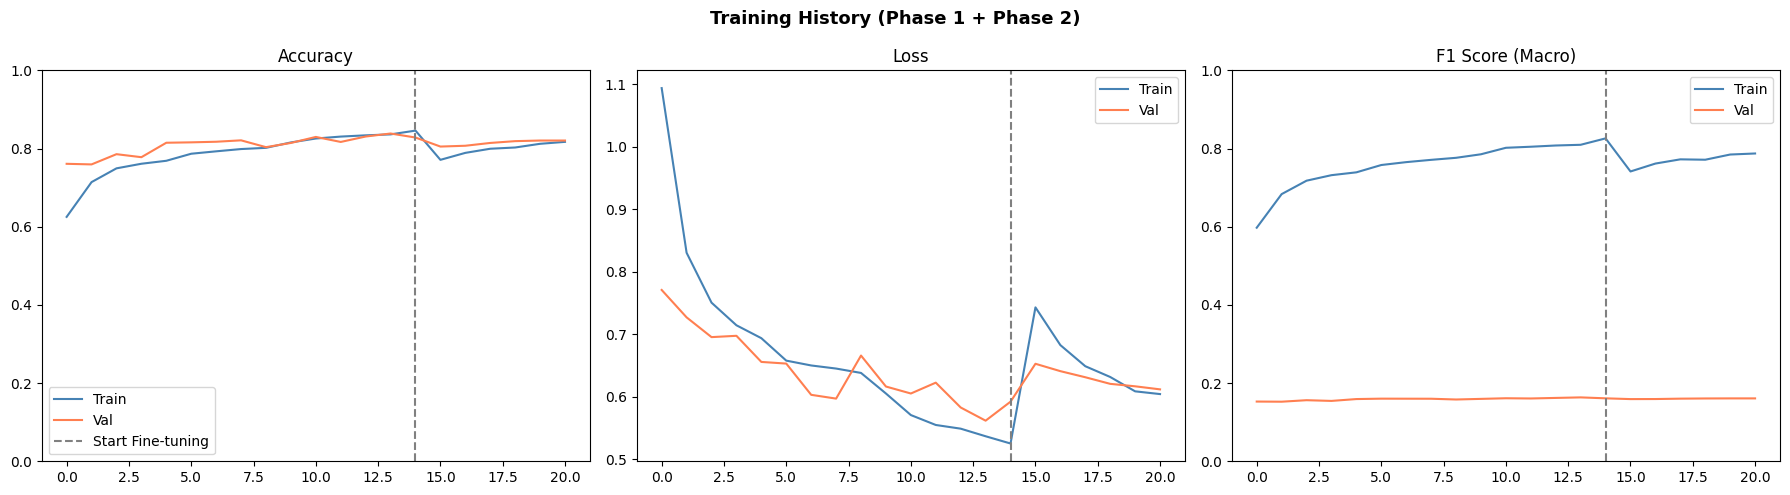

In [12]:
# ===================== TRAINING (TWO PHASES) =====================
CHECKPOINT_PATH = f"{DRIVE_SAVE_DIR}/best_dental_model.keras"

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_f1_score_metric', mode='max',
        patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_f1_score_metric', mode='max',
        factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH, monitor='val_f1_score_metric',
        mode='max', save_best_only=True, verbose=1
    )
]

print(f"🚀 PHASE 1: Training Head (Feature Extraction)...")
history_phase1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15, # Shorter initial train
    class_weight=class_weight_dict,
    callbacks=callbacks
)

# ── PHASE 2: Fine-Tuning ───────────────────────────────────────
print(f"\n🚀 PHASE 2: Fine-tuning top 30 layers of EfficientNet...")
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a MUCH lower learning rate (1e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score_metric]
)

history_phase2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

model.save(f"{DRIVE_SAVE_DIR}/dental_model_final.keras")
print(f"\n✅ Model saved to Drive")

# ── Combine Histories for Plotting ─────────────────────────────
hist_dict = {}
for k in history_phase1.history.keys():
    hist_dict[k] = history_phase1.history[k] + history_phase2.history[k]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase1_epochs = len(history_phase1.history['accuracy'])

axes[0].plot(hist_dict['accuracy'],     label='Train', color='steelblue')
axes[0].plot(hist_dict['val_accuracy'], label='Val',   color='coral')
axes[0].axvline(phase1_epochs-1, color='gray', linestyle='--', label='Start Fine-tuning')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_ylim(0,1)

axes[1].plot(hist_dict['loss'],         label='Train', color='steelblue')
axes[1].plot(hist_dict['val_loss'],     label='Val',   color='coral')
axes[1].axvline(phase1_epochs-1, color='gray', linestyle='--')
axes[1].set_title('Loss'); axes[1].legend()

axes[2].plot(hist_dict['f1_score_metric'],     label='Train', color='steelblue')
axes[2].plot(hist_dict['val_f1_score_metric'], label='Val',   color='coral')
axes[2].axvline(phase1_epochs-1, color='gray', linestyle='--')
axes[2].set_title('F1 Score (Macro)'); axes[2].legend(); axes[2].set_ylim(0,1)

plt.suptitle('Training History (Phase 1 + Phase 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE_DIR}/training_curves.png", dpi=120)
plt.show()

## Cell 6 — Testing


         MODEL EVALUATION ON TEST SET
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step

📊 TEST METRICS
─────────────────────────────────────────────
  Accuracy             : 0.7958  (79.58%)
  F1 Score (Macro)     : 0.7955
  F1 Score (Weighted)  : 0.7965

📋 PER-CLASS F1 SCORES
─────────────────────────────────────────────
  ⚠️  Calculus                  0.6411  ████████████
  ⚠️  Caries                    0.7470  ██████████████
  ⚠️  Gingivitis                0.7114  ██████████████
  ✅ Hypodontia                0.9215  ██████████████████
  ✅ Tooth_Discoloration       0.8458  ████████████████
  ✅ Ulcer                     0.9062  ██████████████████

📄 CLASSIFICATION REPORT
                     precision    recall  f1-score   support

           Calculus     0.5282    0.8154    0.6411       195
             Caries     0.9145    0.6314    0.7470       491
         Gingivitis     0.7155    0.7074    0.7114       352
         Hypodontia     0.8792    0.9681    0.9215       188
Tooth_Discoloration

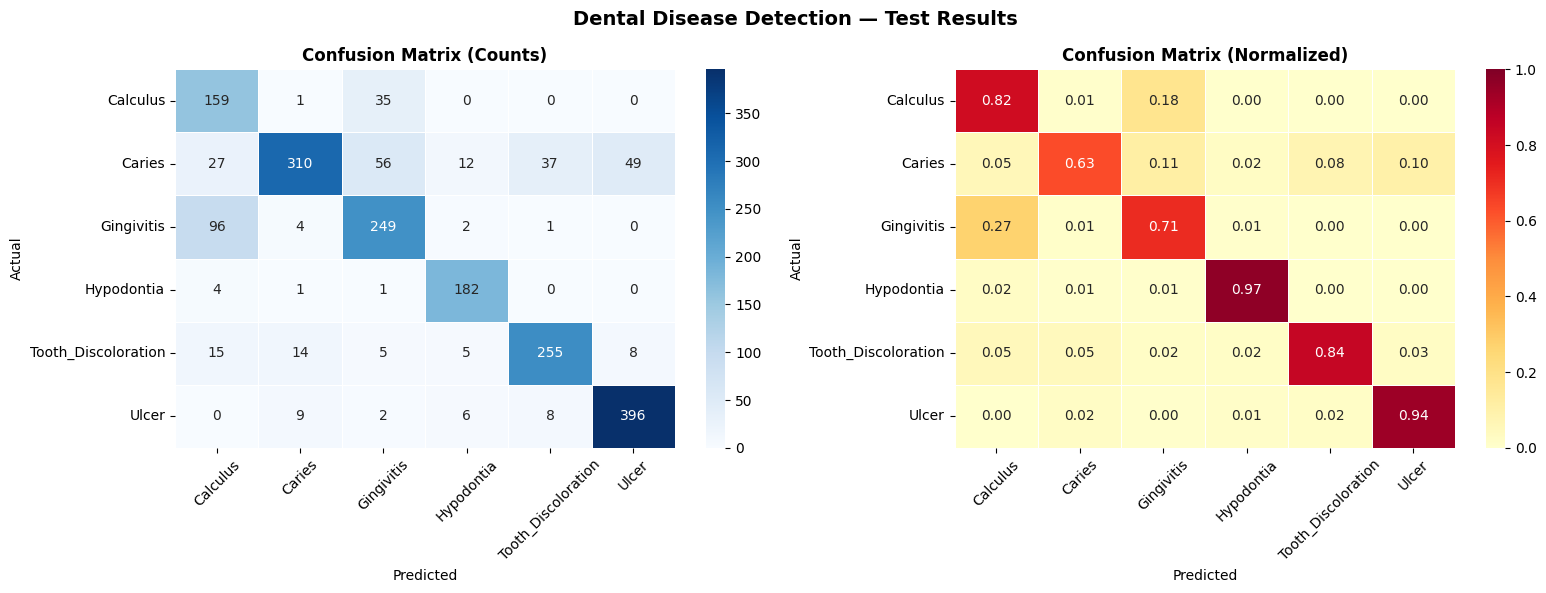

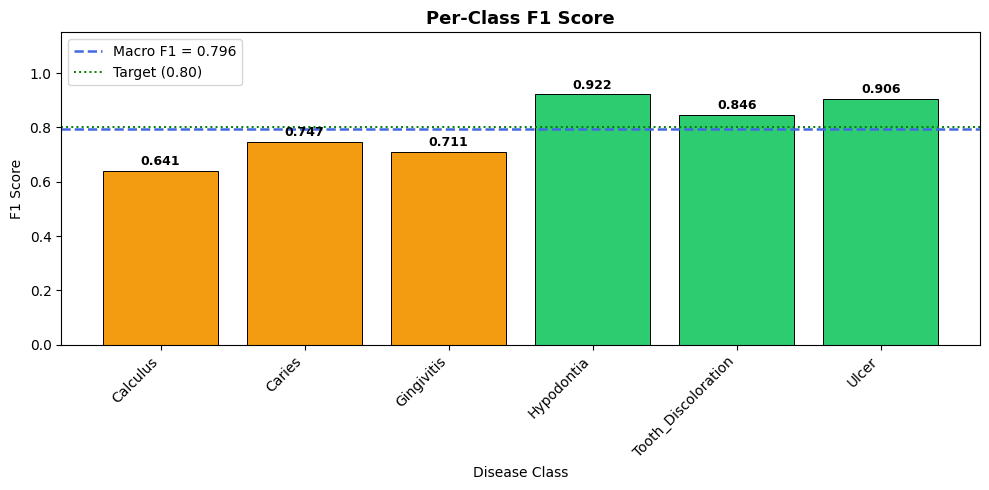


✅ Done!
   Best  : Hypodontia  (F1=0.9215)
   Worst : Calculus  (F1=0.6411)
   All plots saved to Drive ✅


In [13]:
# ===================== COMPREHENSIVE TESTING =====================
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score as sklearn_f1)
import seaborn as sns

print("\n" + "="*60)
print("         MODEL EVALUATION ON TEST SET")
print("="*60)

test_gen.reset()
y_pred_probs   = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true         = test_gen.classes

assert len(y_pred_classes) == len(y_true), \
    f"❌ Mismatch: {len(y_pred_classes)} preds vs {len(y_true)} labels"

test_acc     = accuracy_score(y_true, y_pred_classes)
f1_macro     = sklearn_f1(y_true, y_pred_classes, average='macro')
f1_weighted  = sklearn_f1(y_true, y_pred_classes, average='weighted')
f1_per_class = sklearn_f1(y_true, y_pred_classes, average=None)

print(f"\n📊 TEST METRICS")
print(f"{'─'*45}")
print(f"  Accuracy             : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  F1 Score (Macro)     : {f1_macro:.4f}")
print(f"  F1 Score (Weighted)  : {f1_weighted:.4f}")

print(f"\n📋 PER-CLASS F1 SCORES")
print(f"{'─'*45}")
for cls, score in zip(CLASS_NAMES, f1_per_class):
    bar    = '█' * int(score * 20)
    status = '✅' if score >= 0.8 else '⚠️ ' if score >= 0.6 else '❌'
    print(f"  {status} {cls:<25} {score:.4f}  {bar}")

print(f"\n📄 CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_classes,
                             target_names=CLASS_NAMES, digits=4))

cm            = confusion_matrix(y_true, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='Blues', linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_normalized, annot=True, fmt='.2f', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='YlOrRd', linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Dental Disease Detection — Test Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE_DIR}/confusion_matrix.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if s >= 0.8 else '#f39c12' if s >= 0.6 else '#e74c3c'
          for s in f1_per_class]
bars = ax.bar(CLASS_NAMES, f1_per_class, color=colors,
              edgecolor='black', linewidth=0.7)
ax.axhline(y=f1_macro, color='royalblue', linestyle='--',
           linewidth=1.8, label=f'Macro F1 = {f1_macro:.3f}')
ax.axhline(y=0.8, color='green', linestyle=':', linewidth=1.4, label='Target (0.80)')
for bar, score in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Disease Class'); ax.set_ylabel('F1 Score')
ax.legend(); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{DRIVE_SAVE_DIR}/f1_per_class.png", dpi=120)
plt.show()

print(f"\n✅ Done!")
print(f"   Best  : {CLASS_NAMES[np.argmax(f1_per_class)]}  (F1={max(f1_per_class):.4f})")
print(f"   Worst : {CLASS_NAMES[np.argmin(f1_per_class)]}  (F1={min(f1_per_class):.4f})")
print(f"   All plots saved to Drive ✅")

## Random Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


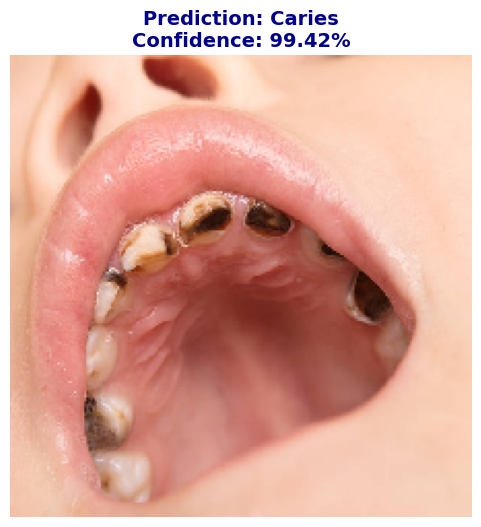

Detailed Analysis for 105.jpg:
  Calculus             :   0.02%
  Caries               :  99.42%
  Gingivitis           :   0.03%
  Hypodontia           :   0.00%
  Tooth_Discoloration  :   0.53%
  Ulcer                :   0.00%


In [33]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_dental_image(img_path, model, class_names):
    # 1. Load and Preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)

    # ⚠️ IMPORTANT: Do NOT rescale by 1/255.0 because
    # EfficientNet handles normalization internally.
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. Get Prediction
    preds = model.predict(img_batch)
    score = np.max(preds[0])
    class_idx = np.argmax(preds[0])
    condition = class_names[class_idx]

    # 3. Visualize
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {condition}\nConfidence: {score*100:.2f}%",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()

    print(f"Detailed Analysis for {os.path.basename(img_path)}:")
    for i, name in enumerate(class_names):
        print(f"  {name:<20} : {preds[0][i]*100:>6.2f}%")

# --- HOW TO USE ---
# Step 1: Upload a random image to the Colab 'Files' sidebar (folder icon)
# Step 2: Replace 'my_tooth.jpg' with your filename below

my_image_path = "/content/dental/Data caries/Data caries/caries orignal data set/done/105.jpg"
predict_dental_image(my_image_path, model, CLASS_NAMES)